# Planner Tests

Most data from lecture_examples/IP-X-1-Automated_PlanerTest.ipynb

Adding all planners
===========


In [1]:
import sys
from pathlib import Path
import matplotlib.pylab as plt
%matplotlib inline
import traceback

# Define paths
REPO_ROOT = Path.cwd().parent               # Repo root (ikp-sbl)
LECTURE_EXAMPLES = REPO_ROOT / "lecture_examples"

# Add BOTH to sys.path
for path in [str(REPO_ROOT), str(LECTURE_EXAMPLES)]:
    if path not in sys.path:
        sys.path.insert(0, path)

# 1. Imports from lecture_examples
from IPPerfMonitor import IPPerfMonitor
import IPBasicPRM
import IPVISBasicPRM
import IPLazyPRM
import IPVISLazyPRM
import IPRRT
import IPVISRRT

# 2. Other imports
from planners.SBL import SBL
from modules import IPVISsbl
# from modules import draw

Set-up of the test scenario and the configuration for all planners
===================================

Following a procedure to compare all discussed planners are shown:

1. Configuration for every planner is defined
2. The configuration and the planner is stored in the variable setup, a Python dict()
3. The variable setup is then used to uniformly execute the planners


In [2]:
# Create a factory for your parameter variations
plannerFactory = dict()

config = SBL.DEFAULT_CONFIG.copy()
config["eta"] = 2.0
plannerFactory[f"SBL"] = [SBL, config, IPVISsbl.sblVisualize]

# Example: Testing different Eta settings
# for eta in [0.5, 1.0, 2.0]:
#     config = SBL.DEFAULT_CONFIG.copy()
#     config["eta"] = eta
#     plannerFactory[f"SBL_eta_{eta}"] = [SBL, config]

# # Example: Testing different Goal Bias settings
# for bias in [0.2, 0.5, 0.8]:
#     config = SBL.DEFAULT_CONFIG.copy()
#     config["goal_bias"] = bias
#     plannerFactory[f"SBL_bias_{bias}"] = [SBL, config]

In [3]:
basicConfig = dict()
basicConfig["radius"] = 3
basicConfig["numNodes"] = 200
plannerFactory["basePRM"] = [IPBasicPRM.BasicPRM, basicConfig, IPVISBasicPRM.basicPRMVisualize]


basicConfig2 = dict()
basicConfig2["radius"] = 6
basicConfig2["numNodes"] = 600
plannerFactory["basePRM2"] = [IPBasicPRM.BasicPRM, basicConfig2, IPVISBasicPRM.basicPRMVisualize]

basicConfig3 = dict()
basicConfig3["radius"] = 15
basicConfig3["numNodes"] = 300
plannerFactory["basePRM3"] = [IPBasicPRM.BasicPRM, basicConfig3, IPVISBasicPRM.basicPRMVisualize]

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"]  = 5 
lazyConfig["kNearest"] = 8
lazyConfig["maxIterations"] = 20
plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, IPVISLazyPRM.lazyPRMVisualize]

rrtSimpleConfig = dict()
rrtSimpleConfig["numberOfGeneratedNodes"] = 100 
rrtSimpleConfig["testGoalAfterNumberOfNodes"]  = 10
plannerFactory["simpleRRT"] = [IPRRT.RRTSimple, rrtSimpleConfig, IPVISRRT.rrtPRMVisualize]




In [4]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [5]:
import lecture_examples.IPTestSuite as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting


In [6]:
#import importlib
#importlib.reload(IPTestSuiteSS2024)

In [7]:
fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)

Trap
Bottleneck
Fat bottleneck
MyField


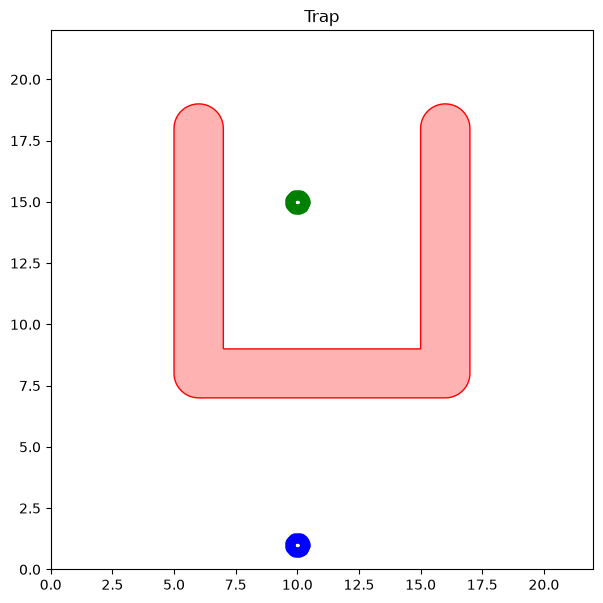

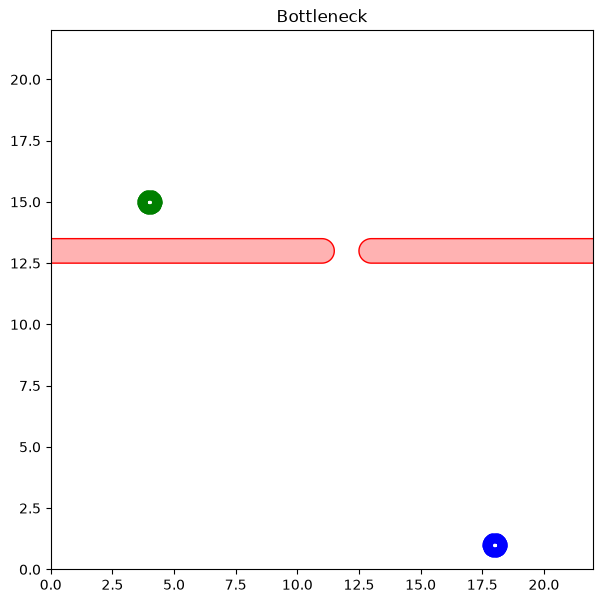

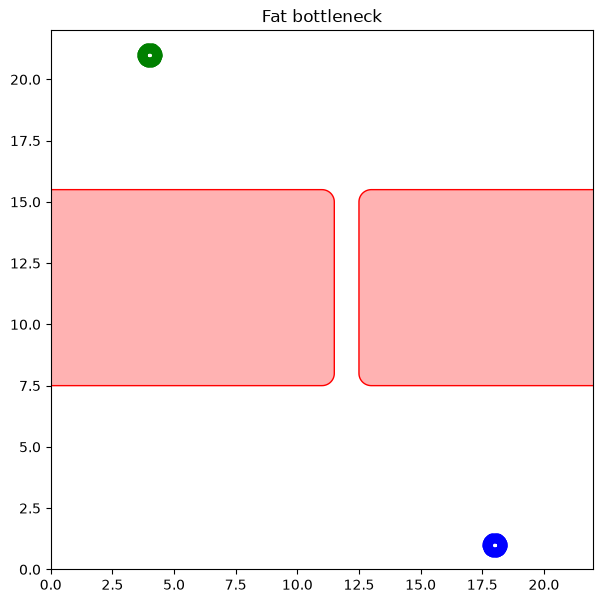

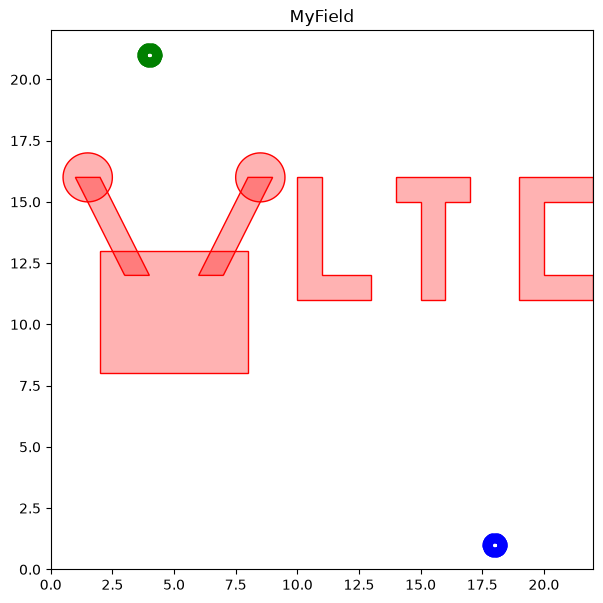

In [8]:
for benchmark in fullBenchList:
    fig_local = plt.figure(figsize=(7,7))
    ax = fig_local.add_subplot(1,1,1)
    title = benchmark.name
    ax.set_title(title)
    ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
    plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
    plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
    #try:
    benchmark.collisionChecker.drawObstacles(ax)
    
        
    #except Exception as e:
    #    print ("Error", e)
    #    pass

    

In [9]:
resultList = list()
testList = fullBenchList

for key, producer in list(plannerFactory.items()):
    print(key, producer)

    planner_class = producer[0]
    config = producer[1]

    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        # 1. Clear data from previous runs
        IPPerfMonitor.clearData()

        # 2. Instantiate and run
        # Note: Depending on the constructor, some planners might not accept config here. 
        # But based on our factory setup, we pass it down if they accept it.
        try:
            planner = planner_class(benchmark.collisionChecker, config=config)
        except TypeError:
            # Fallback if lecture planners don't accept config in their constructor
            planner = planner_class(benchmark.collisionChecker)
        
        try:
            path = planner.planPath(
                benchmark.startList, 
                benchmark.goalList, 
                config
            )

            # 4. Store result using the ResultCollection class
            resultList.append(
                ResultCollection(
                    key,
                    planner, 
                    benchmark, 
                    path, 
                    IPPerfMonitor.dataFrame()
                )
            )
            
        except Exception as e:
            # THIS WILL REVEAL THE EXACT CRASH!
            print(f"CRASH DETECTED for {key} on {benchmark.name}:")
            traceback.print_exc()
            print("-" * 40)


SBL [<class 'planners.SBL.SBL'>, {'max_nodes': 500, 'eta': 2.0, 'standard_eta': 1.5, 'eta_min': 0.05, 'eta_max': 5.0, 'eta_shrink': 0.5, 'eta_grow': 1.2, 'expand_attempts': 5, 'iterations': 10, 'collision_check': {'adaptive': True, 'epsilon': 0.05, 'steps': 50}, 'goal_bias': 0.5, 'repair_bias': 0.6, 'count_edge_checks': False, 'checkpoint_path': None}, <function sblVisualize at 0x113dce8e0>]
Planning: SBL - Trap


100%|██████████| 10/10 [00:00<00:00, 504.85it/s]


Planning: SBL - Bottleneck


100%|██████████| 10/10 [00:00<00:00, 1658.35it/s]


Planning: SBL - Fat bottleneck


 20%|██        | 2/10 [00:00<00:00, 145.28it/s]


Planning: SBL - MyField


 60%|██████    | 6/10 [00:00<00:00, 462.54it/s]

basePRM [<class 'IPBasicPRM.BasicPRM'>, {'radius': 3, 'numNodes': 200}, <function basicPRMVisualize at 0x113aefa60>]
Planning: basePRM - Trap
Planning: basePRM - Bottleneck


Planning: basePRM - Fat bottleneck
Planning: basePRM - MyField
basePRM2 [<class 'IPBasicPRM.BasicPRM'>, {'radius': 6, 'numNodes': 600}, <function basicPRMVisualize at 0x113aefa60>]
Planning: basePRM2 - Trap
Planning: basePRM2 - Bottleneck
Planning: basePRM2 - Fat bottleneck
Planning: basePRM2 - MyField
basePRM3 [<class 'IPBasicPRM.BasicPRM'>, {'radius': 15, 'numNodes': 300}, <function basicPRMVisualize at 0x113aefa60>]
Planning: basePRM3 - Trap
Planning: basePRM3 - Bottleneck
Planning: basePRM3 - Fat bottleneck
Planning: basePRM3 - MyField
lazyPRM [<class 'IPLazyPRM.LazyPRM'>, {'initialRoadmapSize': 10, 'updateRoadmapSize': 5, 'kNearest': 8, 'maxIterations': 20}, <function lazyPRMVisualize at 0x113b08040>]
Planning: lazyPRM - Trap
Planning: lazyPRM - Bottleneck
Planning: lazyPRM - Fat bottleneck
Planning: lazyPRM - MyField
simpleRRT [<class 'IPRRT.RRTSimple'>, {'numberOfGeneratedNodes': 100, 'testGoalAfterNumberOfNodes': 10}, <function rrtPRMVisualize at 0x113b084a0>]
Planning: simpleR

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
/var/folders/2b/sj4wr6sn50jd9nt5d6hpb8l80000gn/T/ipykernel_40781/3627444553.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_local = plt.figure(figsize=(10,10))


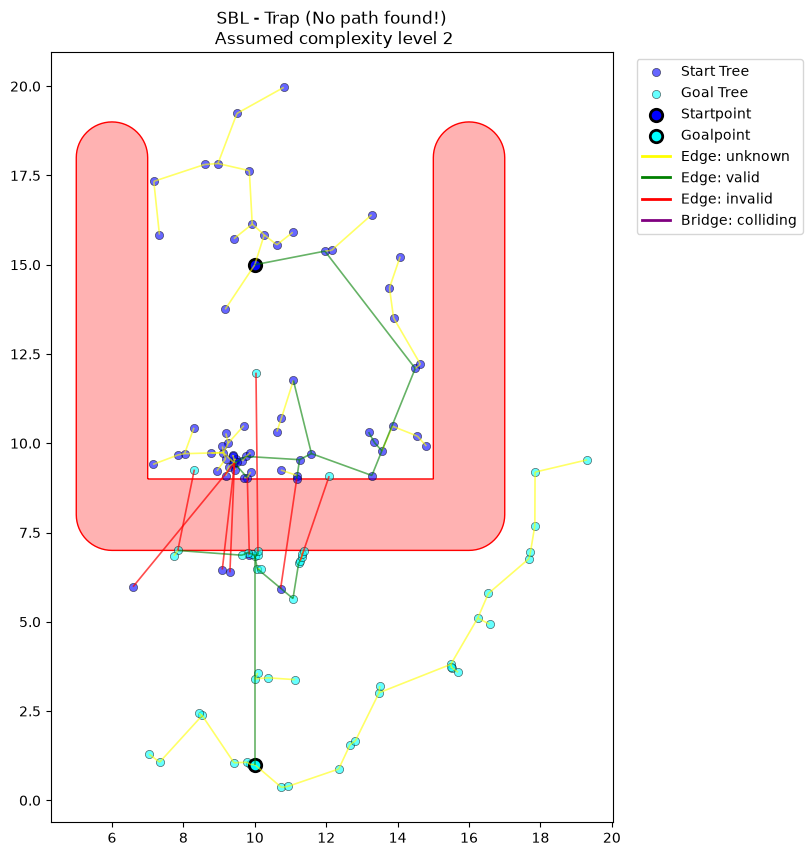

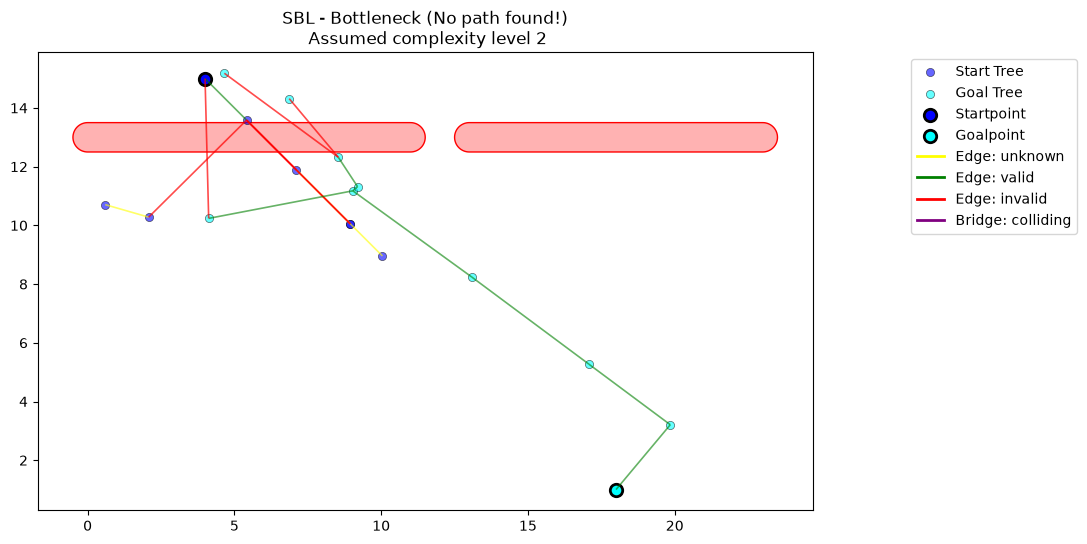

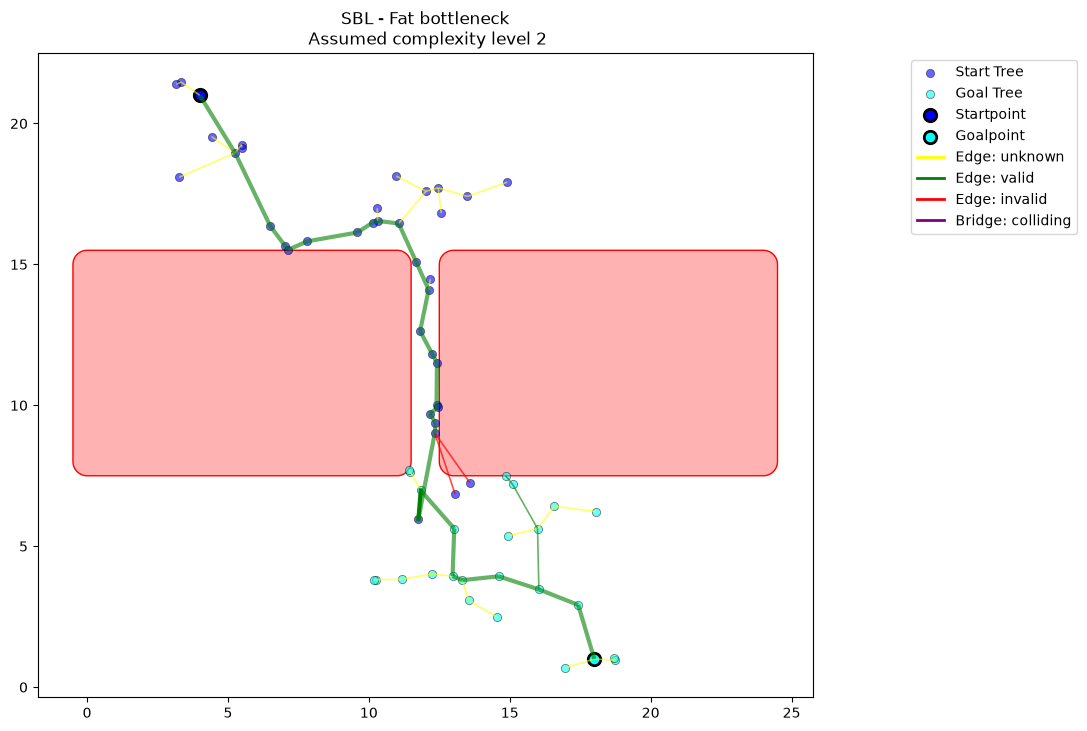

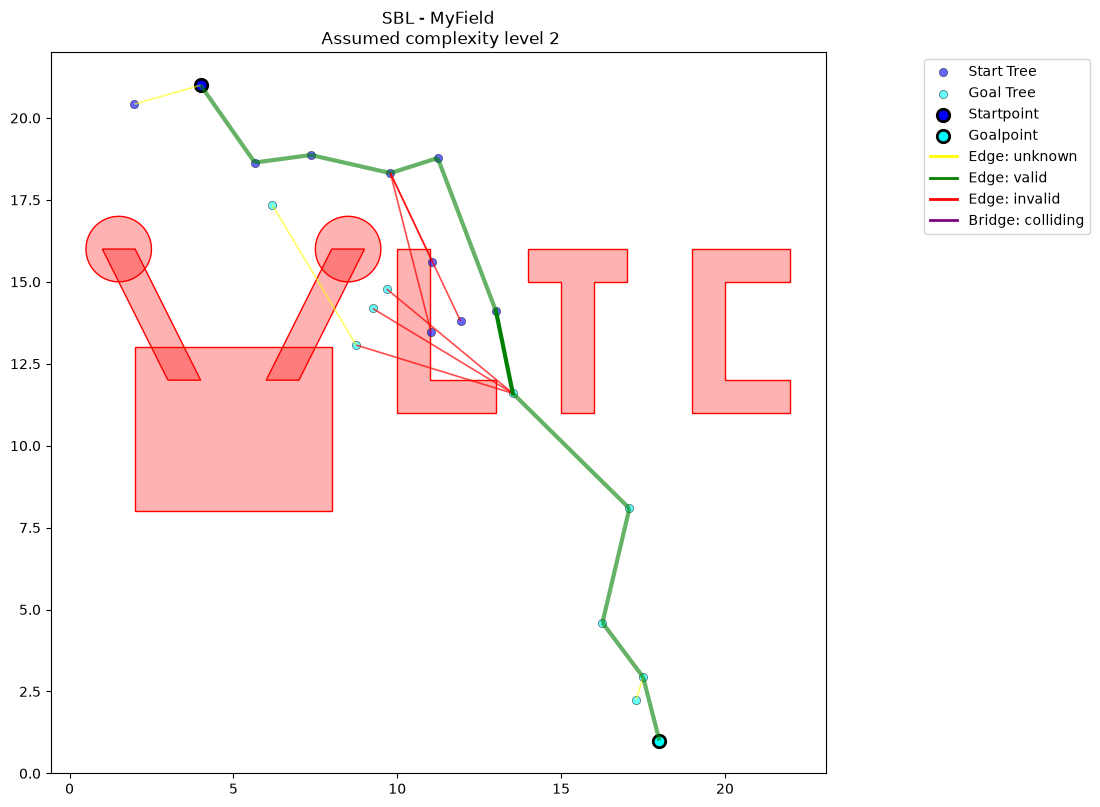

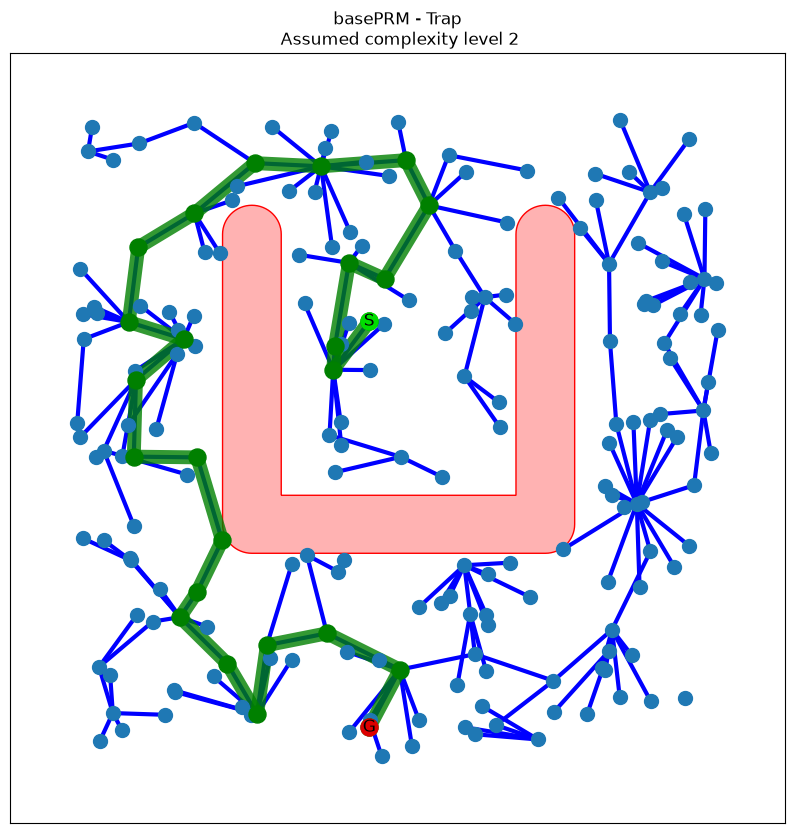

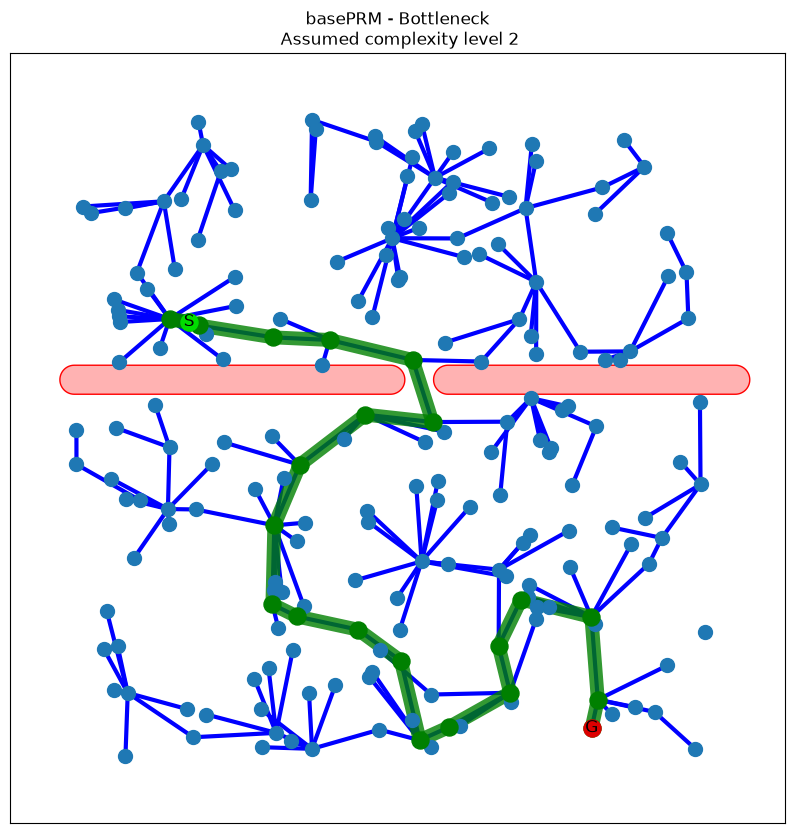

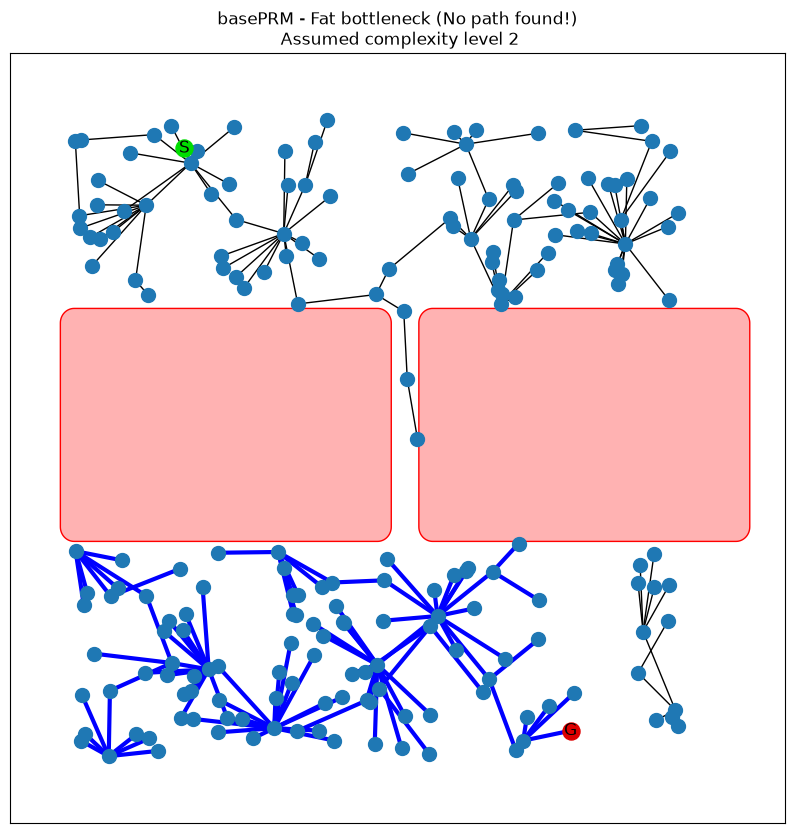

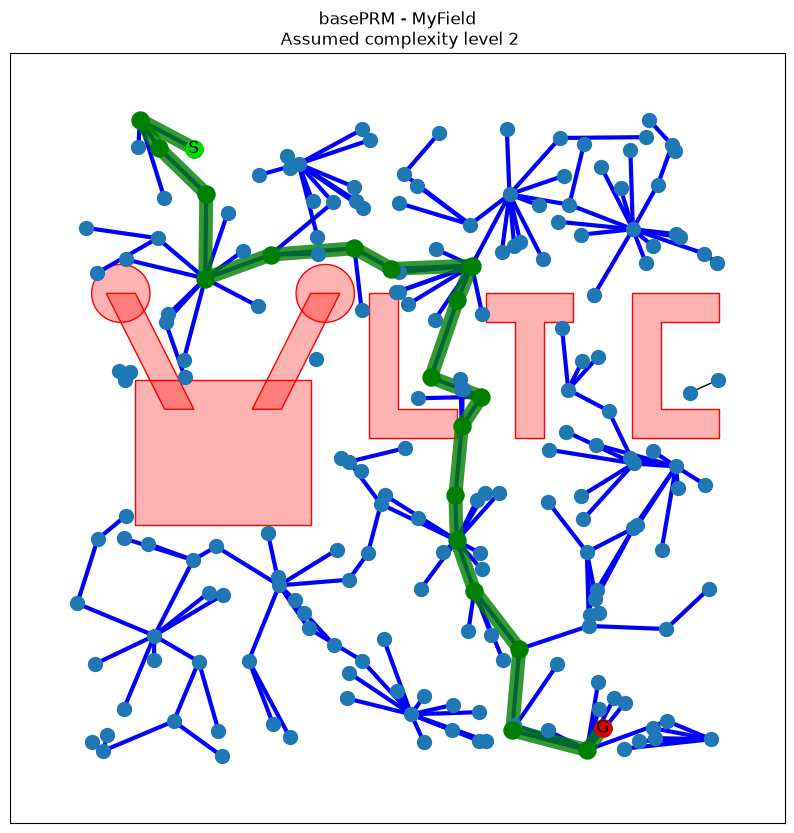

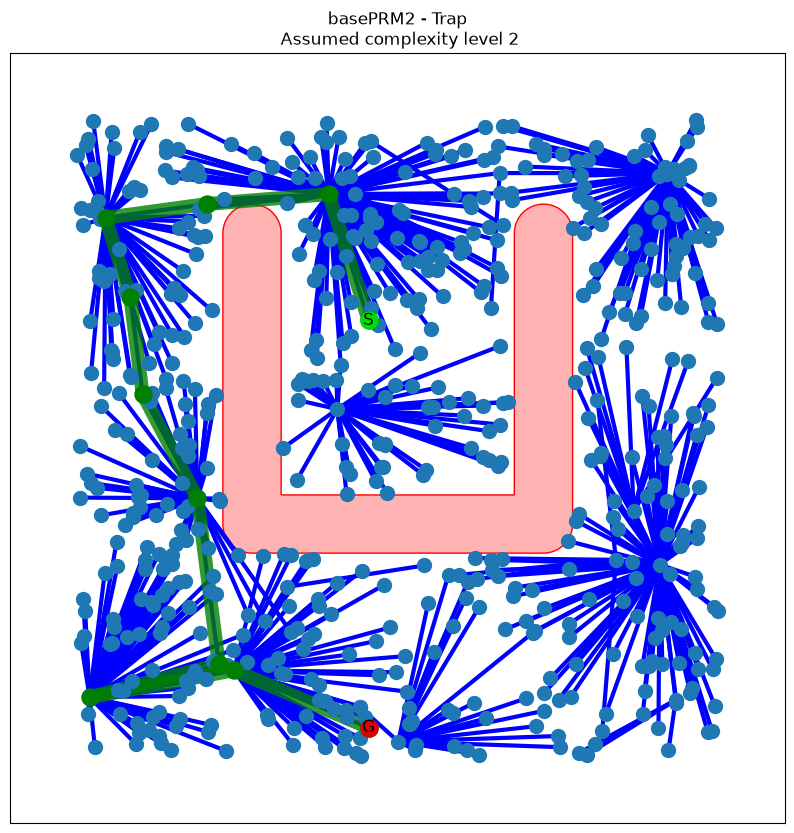

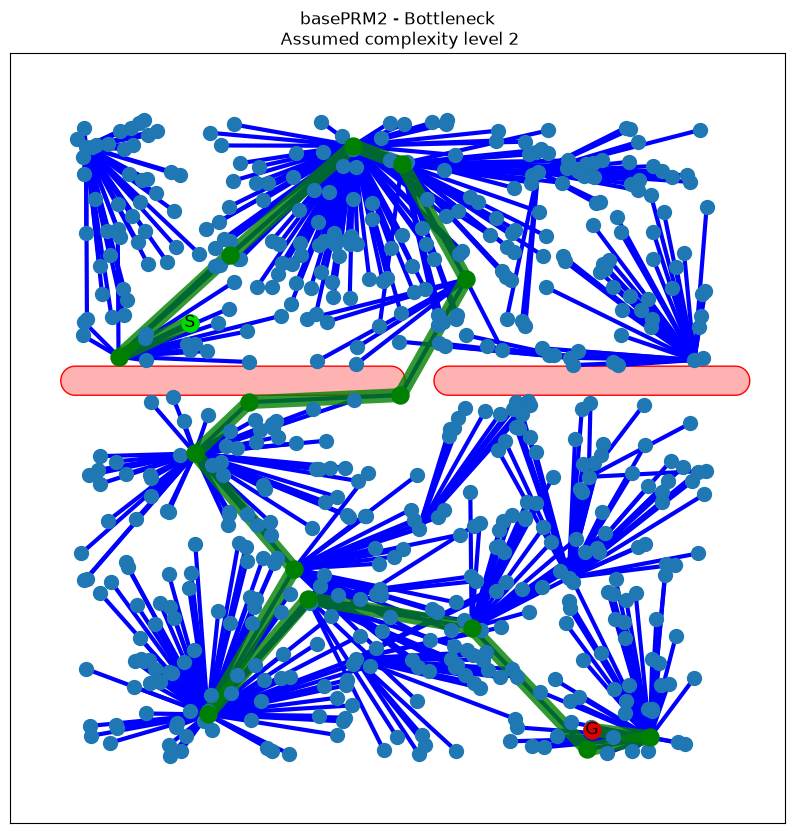

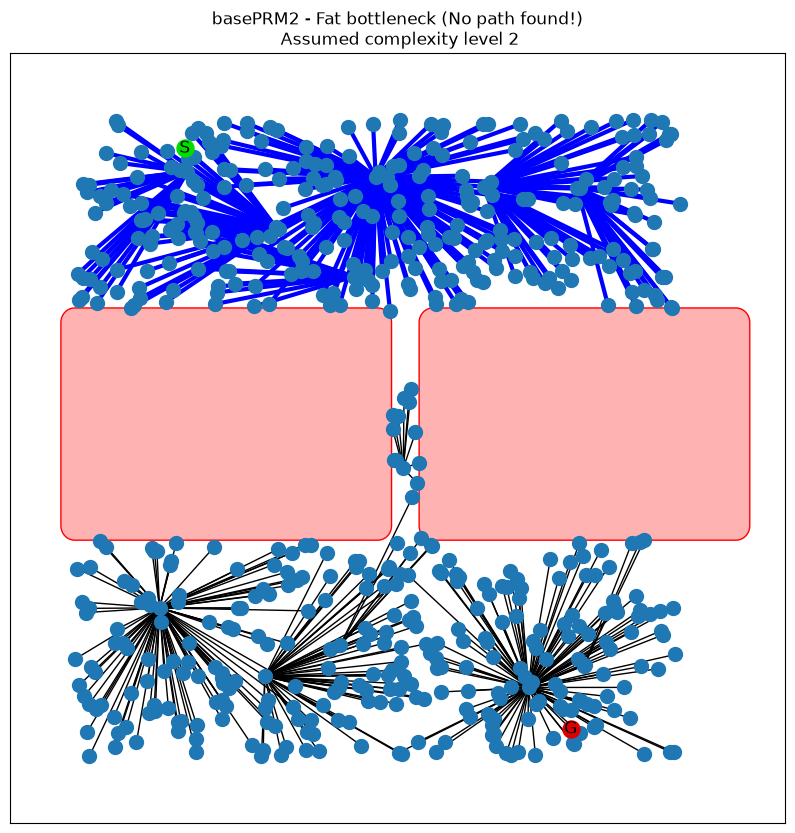

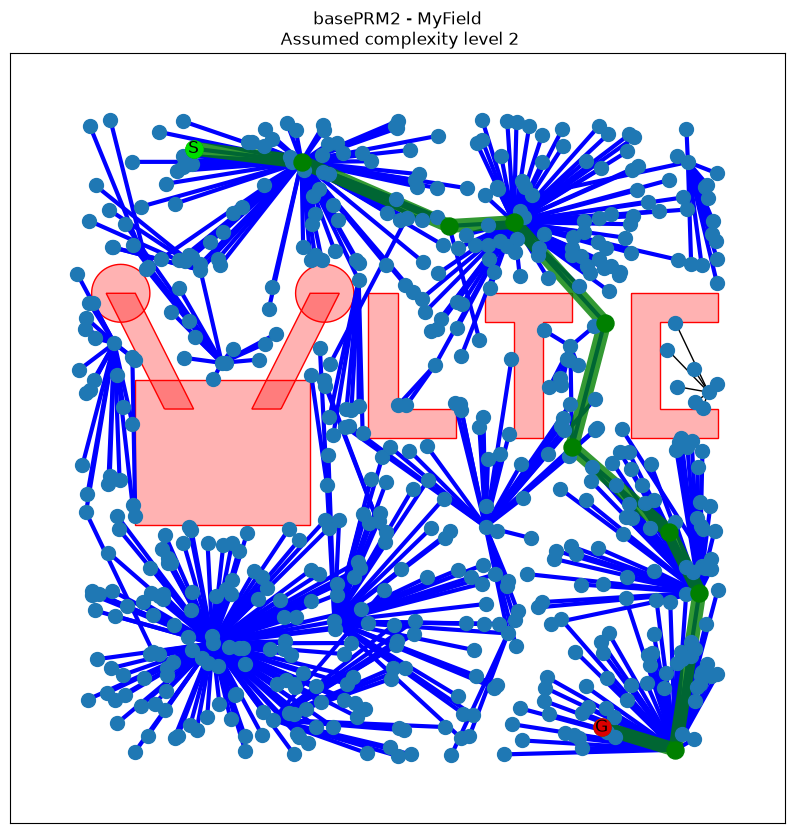

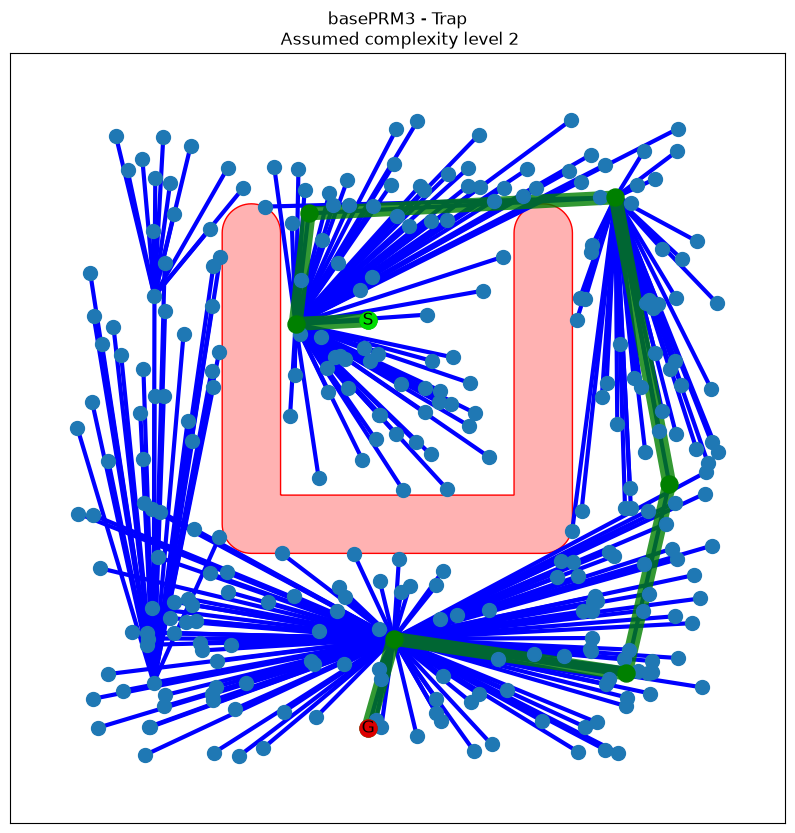

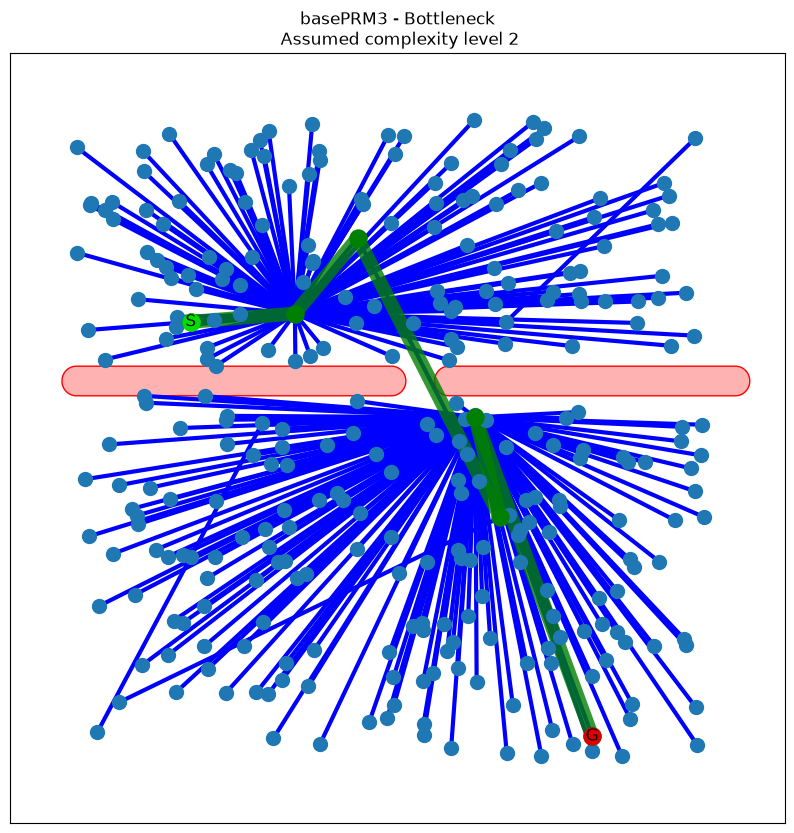

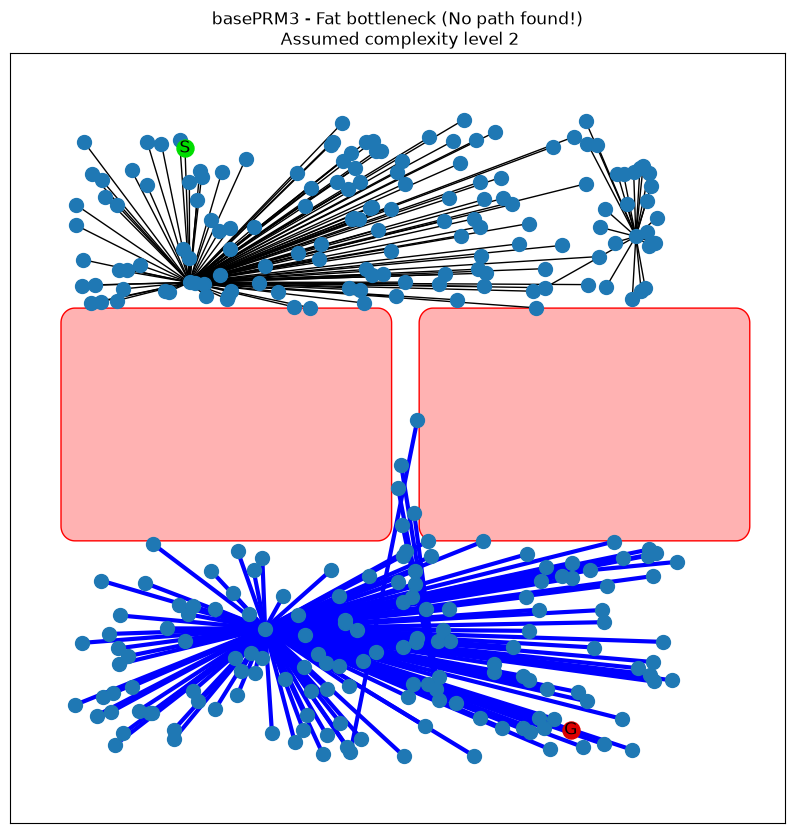

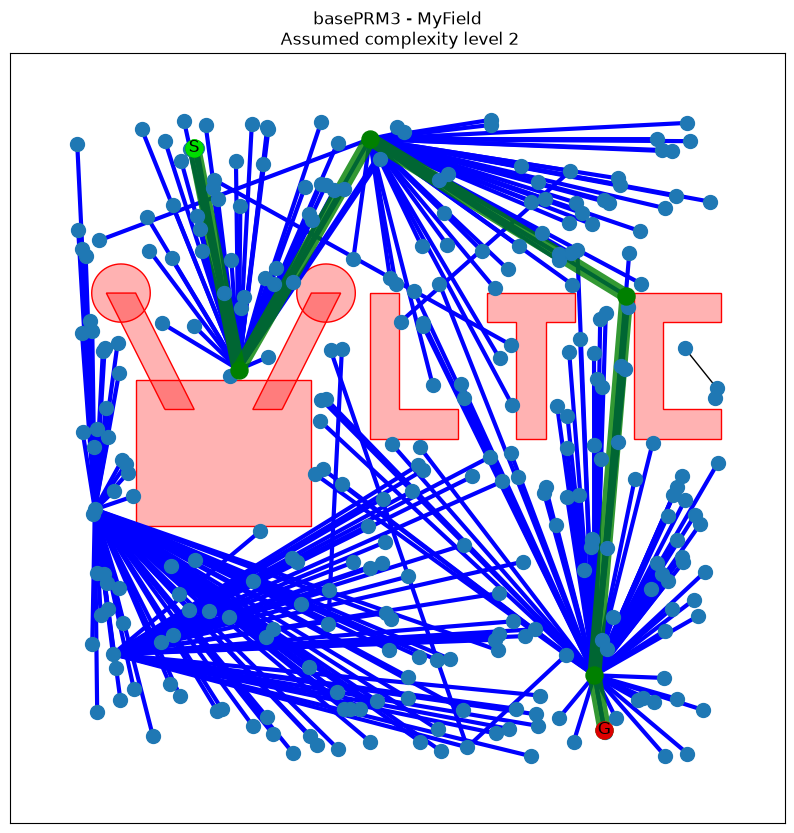

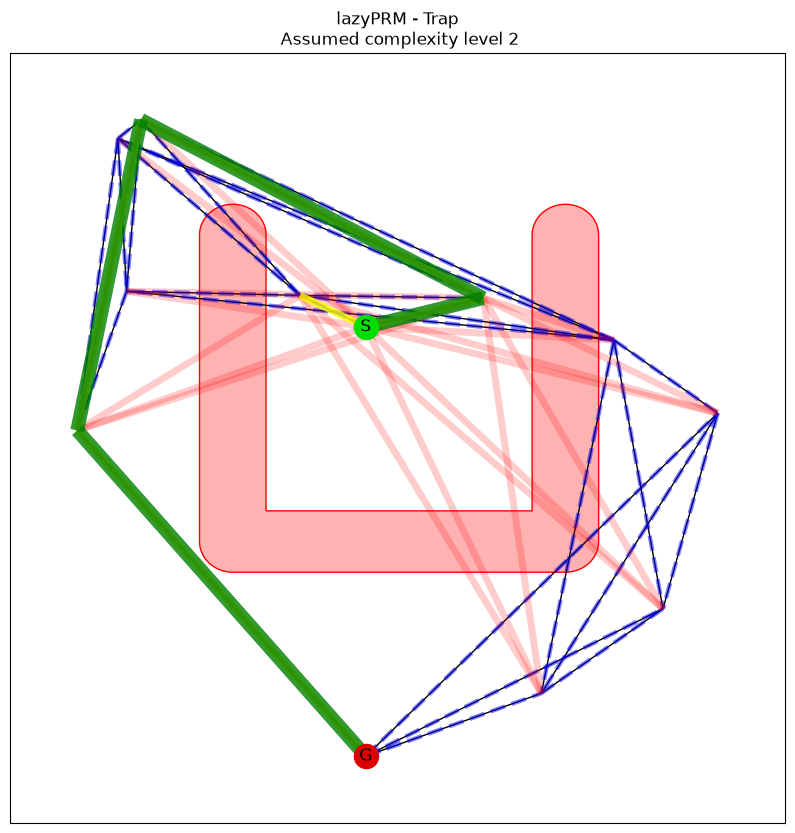

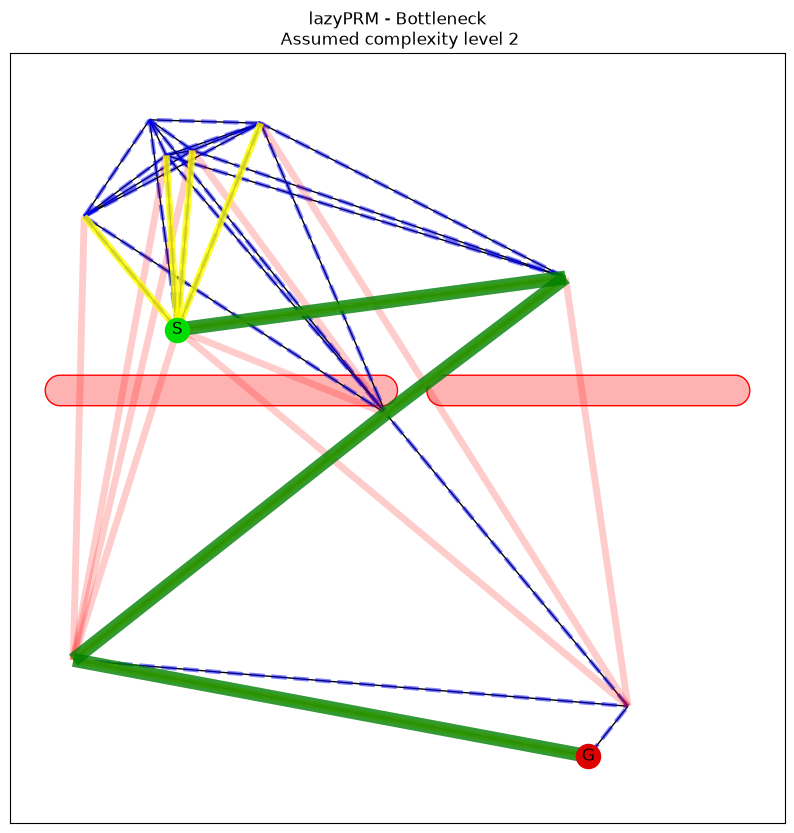

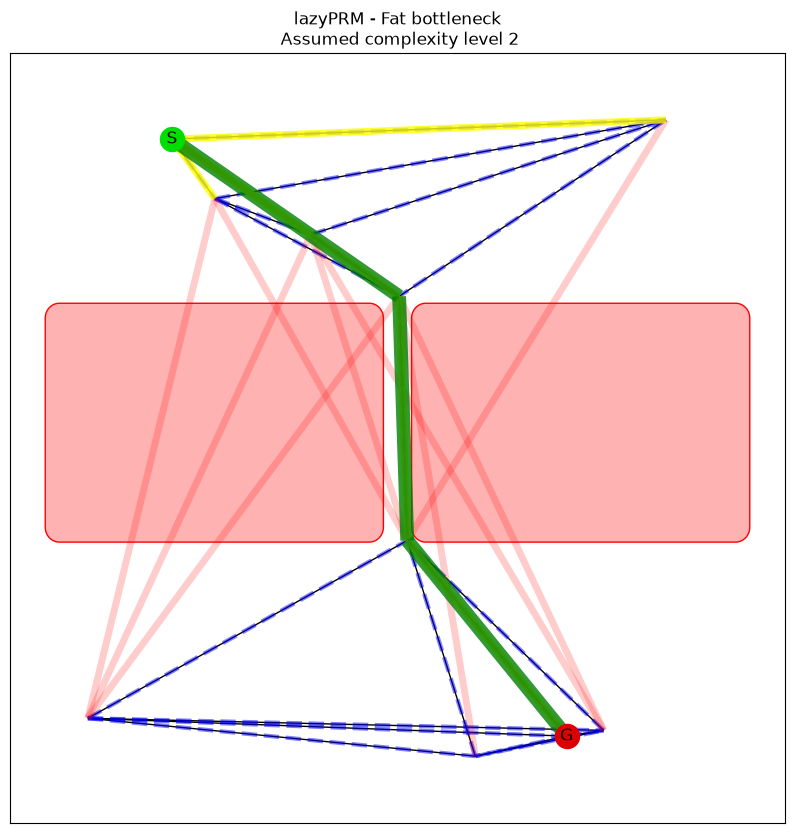

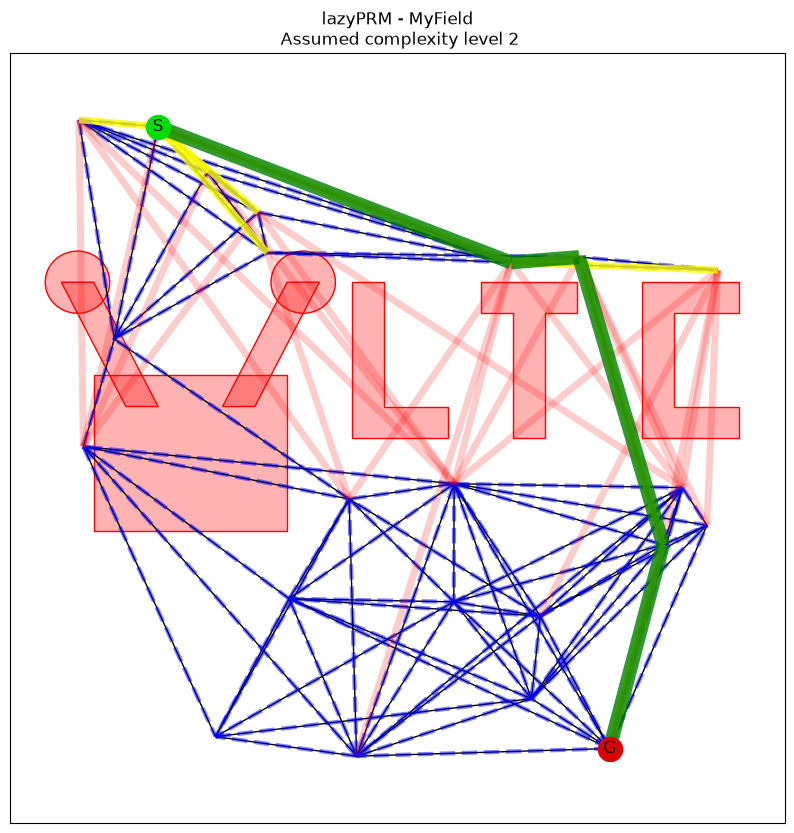

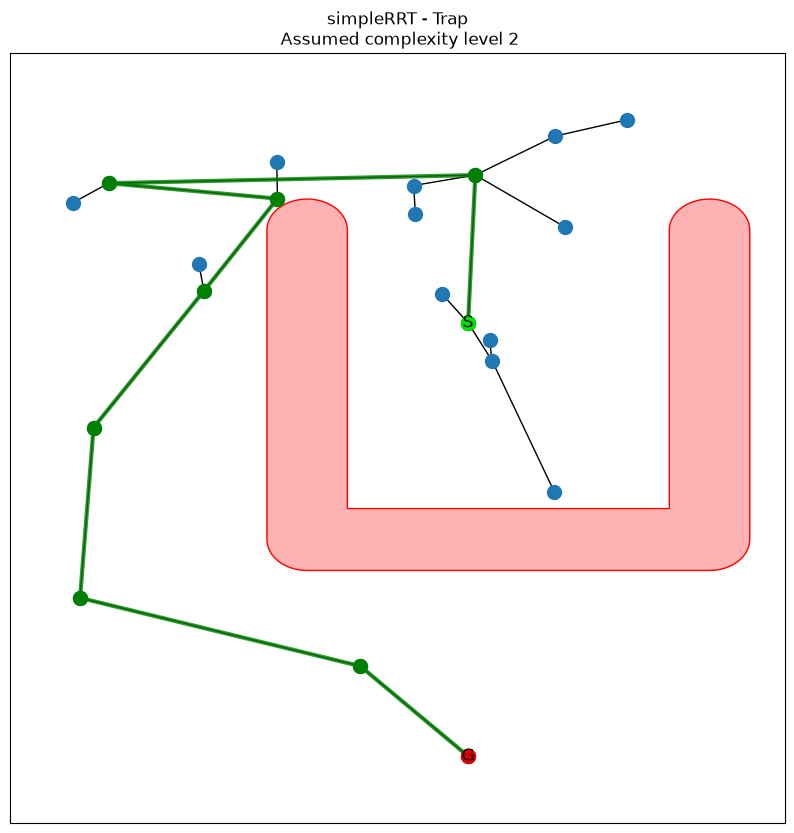

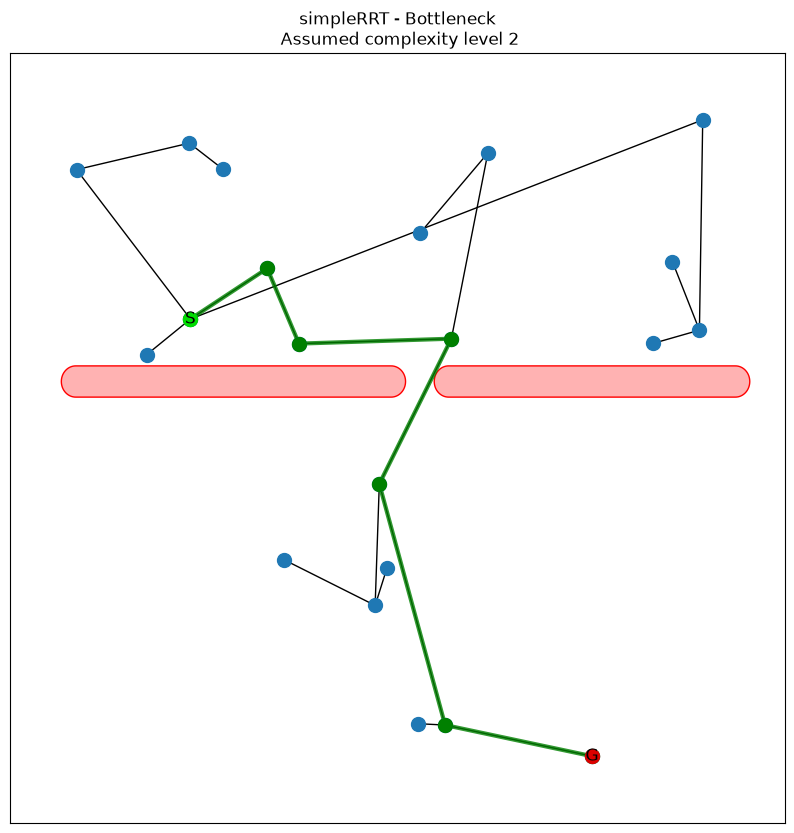

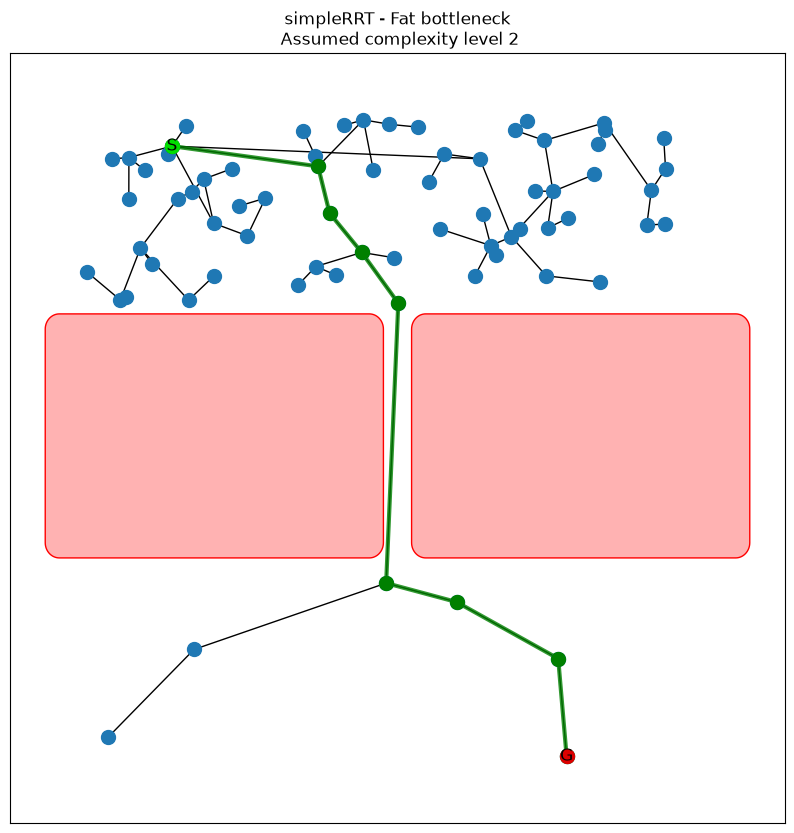

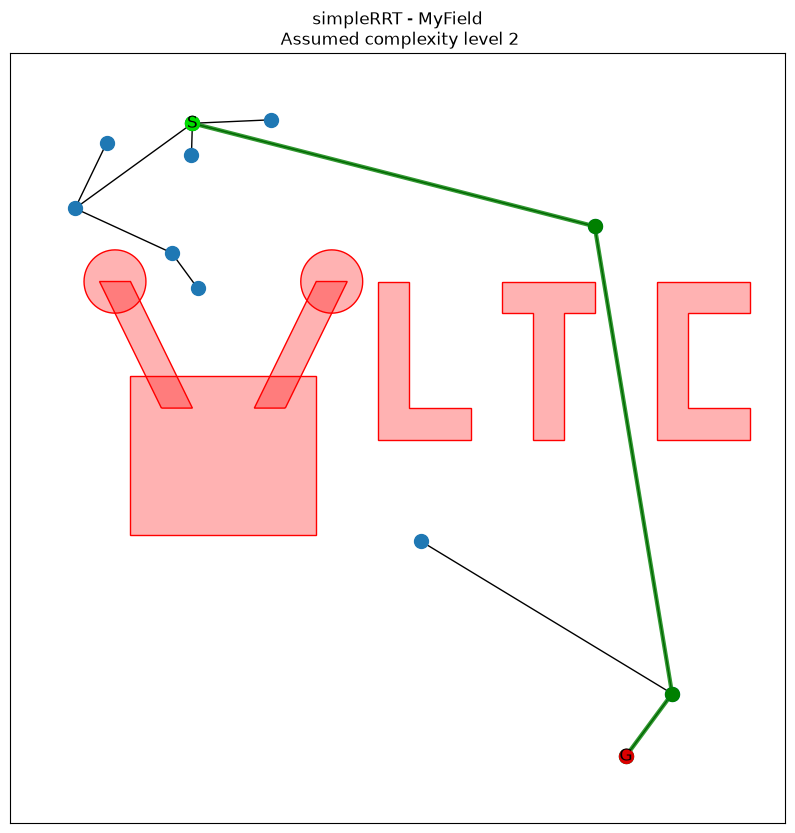

In [10]:
import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(10,10))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        #IPVISBasicPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
    except Exception as e:
        print ("Error", e)
        pass
    

In [11]:
import numpy as np
for bench in testList:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    
    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()


        fig, ax = plt.subplots()

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " Number of nodes in path", color="blue")
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys())

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " Planning time", color="y")

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")
    except:
        pass


    
        
    

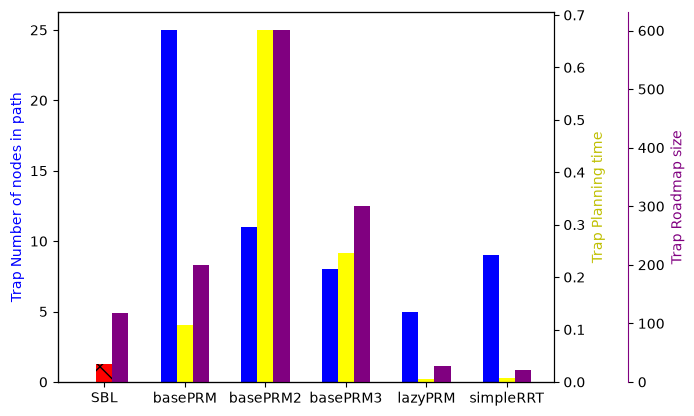

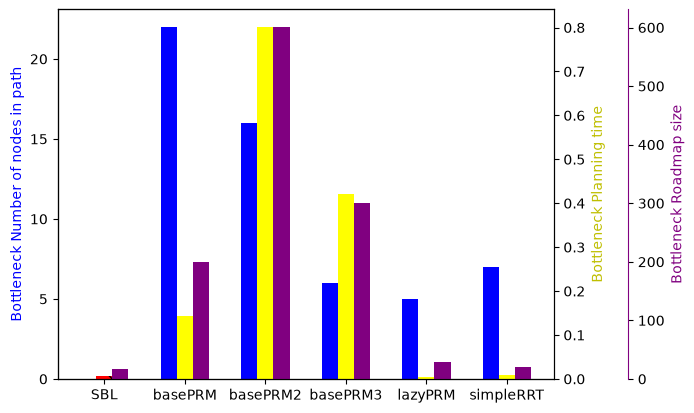

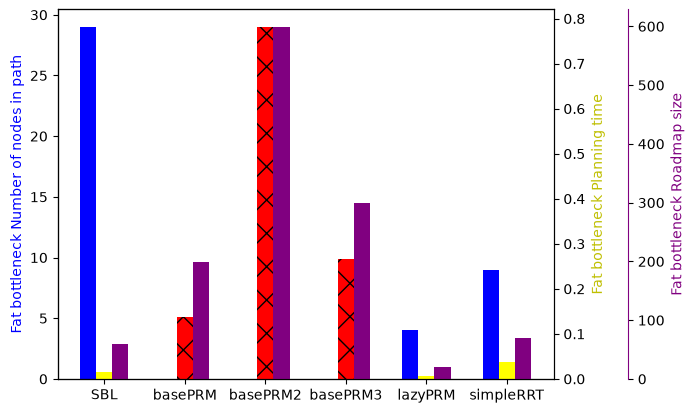

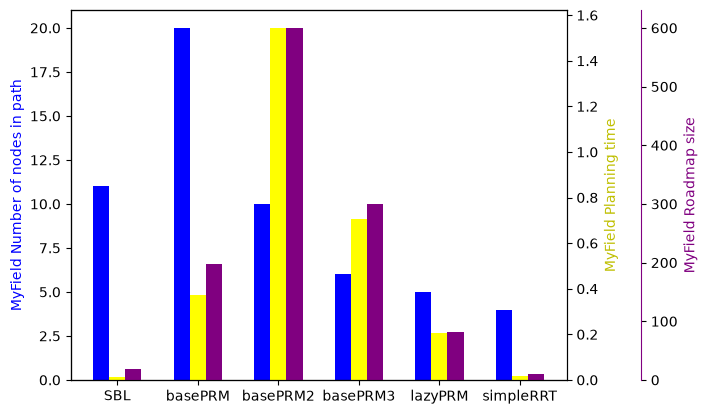

In [12]:
import numpy as np
import matplotlib.pyplot as plt

for bench in testList:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    
    for result in resultList:
        if result.benchmark.name == bench.name:
            # 1. Path length
            pathLength[result.plannerFactoryName] = len(result.solution) if result.solution else 0
            
            # 2. Planning Time
            try:
                # For standard lecture planners using IPPerfMonitor
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
            except KeyError:
                # For SBL: Fallback to the internal stats object
                if hasattr(result.planner, 'stats') and hasattr(result.planner.stats, 'planning_time'):
                    planningTime[result.plannerFactoryName] = result.planner.stats.planning_time
                else:
                    planningTime[result.plannerFactoryName] = 0.0

            # 3. Roadmap Size
            if hasattr(result.planner, 'graph'):
                # For standard PRM planners
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
            elif hasattr(result.planner, 'startTree') and hasattr(result.planner, 'goalTree'):
                # For SBL: Combine the size of both bidirectional trees
                roadmapSize[result.plannerFactoryName] = result.planner.startTree.graph.size() + result.planner.goalTree.graph.size()
            else:
                roadmapSize[result.plannerFactoryName] = 0


    # Skip plotting if no results were found for this benchmark
    if not pathLength:
        continue

    fig, ax = plt.subplots()

    width = 0.2

    ax.bar(np.arange(len(pathLength.keys())), pathLength.values(), width, color="blue")
    ax.set_ylabel(title + " Number of nodes in path", color="blue")
    ax.set_xticks(np.arange(len(pathLength.keys())) + width)
    ax.set_xticklabels(pathLength.keys())

    ax2 = ax.twinx()
    bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(), width, color="red")
    ax2.set_ylabel(title + " Planning time", color="y")

    # Add coloring and patterns on axis two
    hatches = ['x' if length==0 else '' for length in pathLength.values()]
    color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
    for i,thisbar in enumerate(bar.patches):
        thisbar.set_facecolor(color[i])
        thisbar.set_hatch(hatches[i])

    # Multiple axes 
    ax3 = ax.twinx()
    ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(), width, color="purple")
    ax3.set_ylabel(title + " Roadmap size",  color="purple")
    ax3.spines['right'].set_position(('axes', 1.15))
    ax3.spines['right'].set_color("purple")